# The Product Pricer Continued

A model that can estimate how much something costs, from its description.

## Baseline Models

Today we work on the simplest models to act as a starting point that we will beat.

In [1]:
# imports

import os
import math
import json
import random
from dotenv import load_dotenv
from huggingface_hub import login
import matplotlib.pyplot as plt
import numpy as np
import pickle
from collections import Counter

In [2]:
# More imports for our traditional machine learning

import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

## NLP imports

In the next cell, we have more imports for our NLP related machine learning.  
If the gensim import gives you an error like "Cannot import name 'triu' from 'scipy.linalg' then please run in another cell:  
`!pip install "scipy<1.13"`  
As described on StackOverflow [here](https://stackoverflow.com/questions/78279136/importerror-cannot-import-name-triu-from-scipy-linalg-when-importing-gens).  
Many thanks to students Arnaldo G and Ard V for sorting this.

In [3]:
# NLP related imports

from sklearn.feature_extraction.text import CountVectorizer
from gensim.models import Word2Vec
from gensim.utils import simple_preprocess

In [4]:
# Finally, more imports for more advanced machine learning

from sklearn.svm import LinearSVR
from sklearn.ensemble import RandomForestRegressor

In [5]:
# Constants - used for printing to stdout in color

GREEN = "\033[92m"
YELLOW = "\033[93m"
RED = "\033[91m"
RESET = "\033[0m"
COLOR_MAP = {"red":RED, "orange": YELLOW, "green": GREEN}

In [6]:
# environment

load_dotenv(override=True)
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY', 'your-key-if-not-using-env')
os.environ['ANTHROPIC_API_KEY'] = os.getenv('ANTHROPIC_API_KEY', 'your-key-if-not-using-env')
os.environ['HF_TOKEN'] = os.getenv('HF_TOKEN', 'your-key-if-not-using-env')
os.environ['HF_TOKEN3'] = os.getenv('HF_TOKEN3', 'your-key-if-not-using-env')

In [7]:
# Log in to HuggingFace

hf_token = os.environ['HF_TOKEN']
login(hf_token, add_to_git_credential=True)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [8]:
# One more import after logging in

from items import Item

In [9]:
%matplotlib inline

# Loading the pkl files

Let's avoid curating all our data again! Load in the pickle files

If you didn't already create these in Day 2, you can also download them from my google drive (you'll also find the slides here):  
https://drive.google.com/drive/folders/1JwNorpRHdnf_pU0GE5yYtfKlyrKC3CoV?usp=sharing

But note that the files are quite large - you might need to get a coffee!

In [10]:
with open('train.pkl', 'rb') as file:
    train = pickle.load(file)

with open('test.pkl', 'rb') as file:
    test = pickle.load(file)

In [11]:
# Remind ourselves the training prompt

print(train[0].prompt)

How much does this cost to the nearest dollar?

CURT 56422 Vehicle-Side Custom 4-Pin Trailer Wiring Harness, Fits Select Volkswagen Tiguan
If your vehicle is not equipped with wiring for towing a trailer, CURT custom wiring is the ideal solution. A custom wiring harness -- also called a T-connector -- is a simple, plug-and-play electrical device that plugs into your automotive electric system and provides a standard, universal trailer wiring connection. This is done using two or more vehicle-specific, OEM-compatible connectors to plug into the taillight assembly, eliminating the need for cutting, splicing and soldering during installation. Custom wiring harnesses are made vehicle-specific, and while they are not available for all vehicles, they do offer one of the fastest, easiest and most secure ways to wire a vehicle for towing. This particular

Price is $67.00


In [12]:
# Remind a test prompt

print(train[0].price)

67.28


## Unveiling a mighty script that we will use a lot!

A rather pleasing Test Harness that will evaluate any model against 250 items from the Test set

And show us the results in a visually satisfying way.

You write a function of this form:

```
def my_prediction_function(item):
    # my code here
    return my_estimate
```

And then you call:

`Tester.test(my_prediction_function)`

To evaluate your model.

In [13]:
class Tester:

    def __init__(self, predictor, title=None, data=test, size=250):
        self.predictor = predictor
        self.data = data
        self.title = title or predictor.__name__.replace("_", " ").title()
        self.size = size
        self.guesses = []
        self.truths = []
        self.errors = []
        self.sles = []
        self.colors = []

    def color_for(self, error, truth):
        if error<40 or error/truth < 0.2:
            return "green"
        elif error<80 or error/truth < 0.4:
            return "orange"
        else:
            return "red"
    
    def run_datapoint(self, i):
        datapoint = self.data[i]
        guess = self.predictor(datapoint)
        truth = datapoint.price
        error = abs(guess - truth)
        log_error = math.log(truth+1) - math.log(guess+1)
        sle = log_error ** 2
        color = self.color_for(error, truth)
        title = datapoint.title if len(datapoint.title) <= 40 else datapoint.title[:40]+"..."
        self.guesses.append(guess)
        self.truths.append(truth)
        self.errors.append(error)
        self.sles.append(sle)
        self.colors.append(color)
        print(f"{COLOR_MAP[color]}{i+1}: Guess: ${guess:,.2f} Truth: ${truth:,.2f} Error: ${error:,.2f} SLE: {sle:,.2f} Item: {title}{RESET}")

    def chart(self, title):
        max_error = max(self.errors)
        plt.figure(figsize=(12, 8))
        max_val = max(max(self.truths), max(self.guesses))
        plt.plot([0, max_val], [0, max_val], color='deepskyblue', lw=2, alpha=0.6)
        plt.scatter(self.truths, self.guesses, s=3, c=self.colors)
        plt.xlabel('Ground Truth')
        plt.ylabel('Model Estimate')
        plt.xlim(0, max_val)
        plt.ylim(0, max_val)
        plt.title(title)
        plt.show()

    def report(self):
        average_error = sum(self.errors) / self.size
        rmsle = math.sqrt(sum(self.sles) / self.size)
        hits = sum(1 for color in self.colors if color=="green")
        title = f"{self.title} Error=${average_error:,.2f} RMSLE={rmsle:,.2f} Hits={hits/self.size*100:.1f}%"
        self.chart(title)

    def run(self):
        self.error = 0
        for i in range(self.size):
            self.run_datapoint(i)
        self.report()

    @classmethod
    #cls refers to the class Tester.
    #cls(function) creates a new Tester instance with predictor=function.
    #.run() executes the full test flow on it.
    def test(cls, function):
        cls(function).run()

# Now for something basic

What's the very simplest model you could imagine?

Let's start with a random number generator!

In [14]:
def random_pricer(item):
    return random.randrange(1,1000)

1: Guess: $655.00 Truth: $250.56 Error: $404.44 SLE: 0.92 Item: NavePoint 4ft Open Frame 19 Inch 22U 4-P...
2: Guess: $115.00 Truth: $232.18 Error: $117.18 SLE: 0.49 Item: APS Premium 6in iBoard Running Boards Co...
3: Guess: $26.00 Truth: $134.87 Error: $108.87 SLE: 2.61 Item: Peerless PTT188792-BL Tub and Shower Tri...
4: Guess: $760.00 Truth: $357.09 Error: $402.91 SLE: 0.57 Item: TransDeco TD600B Stand with Mount, 85" T...
5: Guess: $282.00 Truth: $258.07 Error: $23.93 SLE: 0.01 Item: ACDelco Professional 45K5008 Front Lower...
6: Guess: $251.00 Truth: $27.95 Error: $223.05 SLE: 4.68 Item: AutoStuff - Camisasca Brushed Finish 2 H...
7: Guess: $229.00 Truth: $170.99 Error: $58.01 SLE: 0.08 Item: HJC Helmets Unisex-Adult Full Face i10 H...
8: Guess: $143.00 Truth: $225.00 Error: $82.00 SLE: 0.20 Item: Magnetic Roller Tip Standard Kit
9: Guess: $755.00 Truth: $105.09 Error: $649.91 SLE: 3.86 Item: Linksys by Cisco Wireless G Broadband Ro...
10: Guess: $105.00 Truth: $299.99 Error: $19

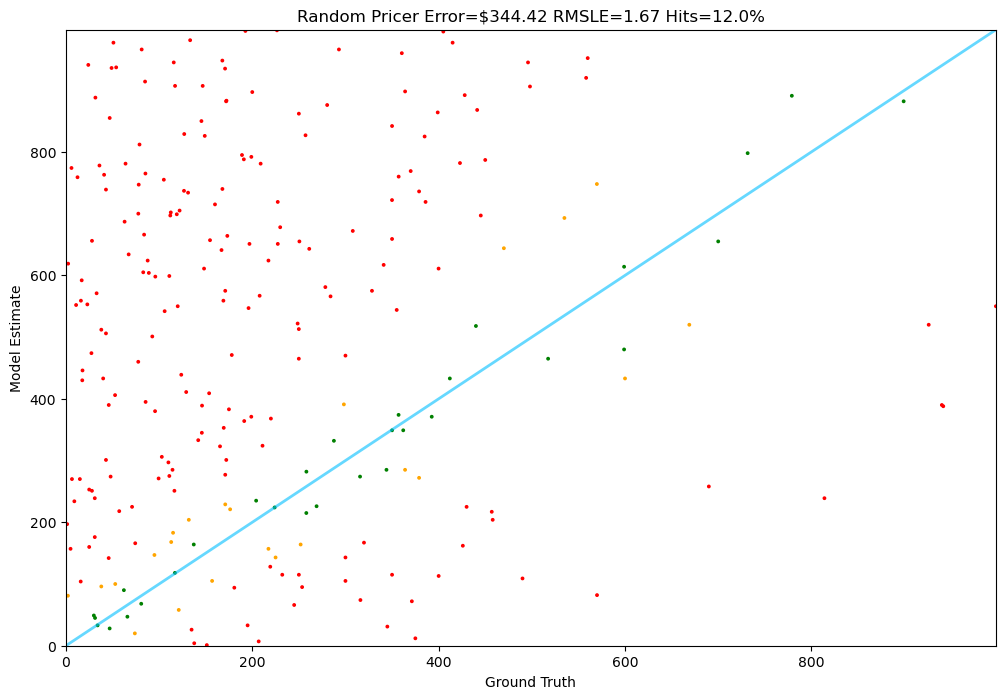

In [15]:
# Set the random seed

random.seed(42)

# Run our TestRunner
Tester.test(random_pricer)

In [16]:
# That was fun!
# We can do better - here's another rather trivial model

training_prices = [item.price for item in train]
training_average = sum(training_prices) / len(training_prices)

def constant_pricer(item):
    return training_average

1: Guess: $220.45 Truth: $250.56 Error: $30.11 SLE: 0.02 Item: NavePoint 4ft Open Frame 19 Inch 22U 4-P...
2: Guess: $220.45 Truth: $232.18 Error: $11.73 SLE: 0.00 Item: APS Premium 6in iBoard Running Boards Co...
3: Guess: $220.45 Truth: $134.87 Error: $85.58 SLE: 0.24 Item: Peerless PTT188792-BL Tub and Shower Tri...
4: Guess: $220.45 Truth: $357.09 Error: $136.64 SLE: 0.23 Item: TransDeco TD600B Stand with Mount, 85" T...
5: Guess: $220.45 Truth: $258.07 Error: $37.62 SLE: 0.02 Item: ACDelco Professional 45K5008 Front Lower...
6: Guess: $220.45 Truth: $27.95 Error: $192.50 SLE: 4.14 Item: AutoStuff - Camisasca Brushed Finish 2 H...
7: Guess: $220.45 Truth: $170.99 Error: $49.46 SLE: 0.06 Item: HJC Helmets Unisex-Adult Full Face i10 H...
8: Guess: $220.45 Truth: $225.00 Error: $4.55 SLE: 0.00 Item: Magnetic Roller Tip Standard Kit
9: Guess: $220.45 Truth: $105.09 Error: $115.36 SLE: 0.54 Item: Linksys by Cisco Wireless G Broadband Ro...
10: Guess: $220.45 Truth: $299.99 Error: $79.54

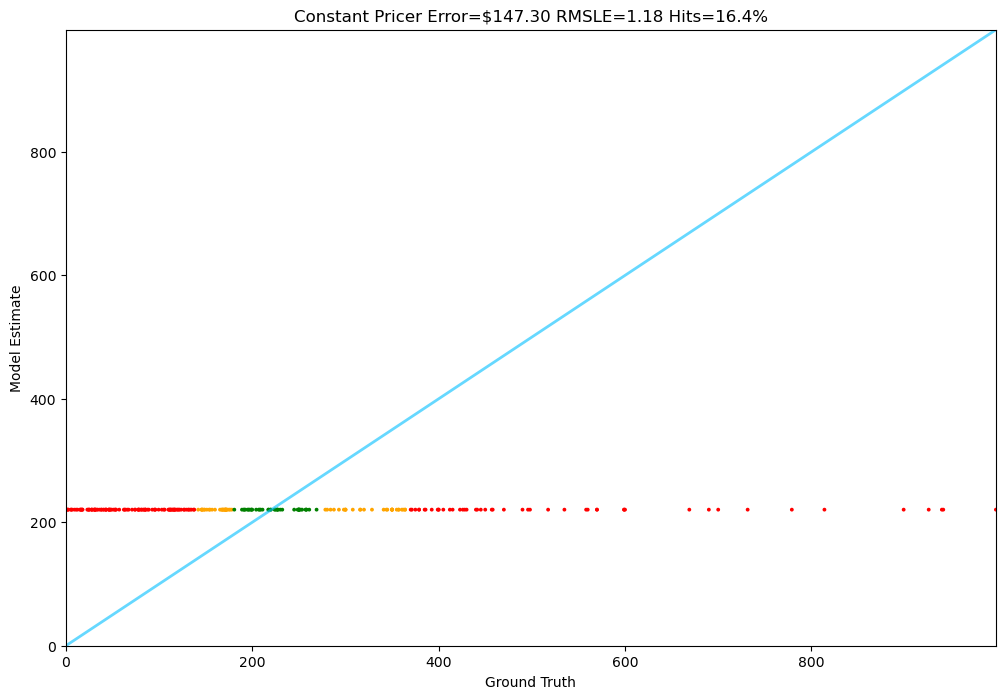

In [17]:
# Run our constant predictor
Tester.test(constant_pricer)


In [18]:
train[0].details

'{"Manufacturer": "CURT", "Brand": "CURT", "Model": "Custom Wiring", "Item Weight": "1.72 pounds", "Product Dimensions": "9 x 6 x 3 inches", "Item model number": "56422", "Exterior": "Painted", "Manufacturer Part Number": "56422", "Best Sellers Rank": {"Automotive": 182673, "Towing Hitch Wiring": 416}, "Date First Available": "February 21, 2020"}'

In [19]:
# Create a new "features" field on items, and populate it with json parsed from the details dict

for item in train:
    item.features = json.loads(item.details)
for item in test:
    item.features = json.loads(item.details)

# Look at one

In [20]:
train[0].features.keys()

dict_keys(['Manufacturer', 'Brand', 'Model', 'Item Weight', 'Product Dimensions', 'Item model number', 'Exterior', 'Manufacturer Part Number', 'Best Sellers Rank', 'Date First Available'])

In [21]:
train[1].features['Best Sellers Rank']

{'Tools & Home Improvement': 1036519, 'Wall Sconces': 6777}

In [22]:
# Look at 20 most common features in training set

feature_count = Counter()
for item in train:
    for f in item.features.keys():
        feature_count[f]+=1

feature_count.most_common(40)

[('Date First Available', 359927),
 ('Item Weight', 350482),
 ('Manufacturer', 349202),
 ('Brand', 340487),
 ('Best Sellers Rank', 330632),
 ('Item model number', 277456),
 ('Product Dimensions', 262371),
 ('Color', 183789),
 ('Is Discontinued By Manufacturer', 169764),
 ('Manufacturer Part Number', 145035),
 ('Material', 137281),
 ('Country of Origin', 121707),
 ('Style', 77541),
 ('Part Number', 74622),
 ('Special Feature', 74550),
 ('Batteries Required?', 73603),
 ('Package Dimensions', 72838),
 ('Item Dimensions LxWxH', 71457),
 ('Included Components', 67518),
 ('Model', 65156),
 ('Item Package Quantity', 58299),
 ('Size', 58062),
 ('Batteries Included?', 56709),
 ('OEM Part Number', 56061),
 ('Special Features', 53814),
 ('Exterior', 50575),
 ('Power Source', 50304),
 ('Vehicle Service Type', 49273),
 ('Finish Type', 46081),
 ('Voltage', 45988),
 ('Mounting Type', 38091),
 ('Model Name', 37494),
 ('Shape', 34989),
 ('Number of Items', 31889),
 ('Finish', 31849),
 ('Connectivity Te

In [23]:
# Now some janky code to pluck out the Item Weight
# Don't worry too much about this: spoiler alert, it's not going to be much use in training!

def get_weight(item):
    weight_str = item.features.get('Item Weight')
    if weight_str:
        parts = weight_str.split(' ')
        amount = float(parts[0])
        unit = parts[1].lower()
        if unit=="pounds":
            return amount
        elif unit=="ounces":
            return amount / 16
        elif unit=="grams":
            return amount / 453.592
        elif unit=="milligrams":
            return amount / 453592
        elif unit=="kilograms":
            return amount / 0.453592
        elif unit=="hundredths" and parts[2].lower()=="pounds":
            return amount / 100
        else:
            print(weight_str)
    return None

In [24]:
weights = [get_weight(t) for t in train]
weights = [w for w in weights if w]

In [25]:
average_weight = sum(weights)/len(weights)
average_weight

13.536604105084567

In [26]:
def get_weight_with_default(item):
    weight = get_weight(item)
    return weight or average_weight

In [27]:
train[0].features['Manufacturer']

'CURT'

In [28]:
import re

def to_inches(value, unit):
    unit = unit.lower()
    if unit in ['inch', 'inches', 'in', '"', '”', '“']:
        return value
    elif unit in ['foot', 'feet', 'ft', "'"]:
        return value * 12
    elif unit in ['cm', 'centimeter', 'centimeters']:
        return value / 2.54
    elif unit in ['m', 'meter', 'meters']:
        return value * 39.3701
    else:
        # Unknown unit
        return None

def parse_dimension_value(dim_str):
    """
    Parses a string with a number and optional unit, returns value in inches or None.
    If no unit detected, assume 0.
    """
    # Find number (including fractions like 1/2)
    frac_match = re.match(r'(\d+)\s*/\s*(\d+)', dim_str)
    if frac_match:
        #num = float(frac_match.group(1)) / float(frac_match.group(2))
        #rest = dim_str[frac_match.end():].strip()
        numerator = float(frac_match.group(1))
        denominator = float(frac_match.group(2))
        if denominator == 0:
            return 0  # avoid division by zero
        num = numerator / denominator
        rest = dim_str[frac_match.end():].strip()
    else:
        # Match decimal or integer number at start
        num_match = re.match(r'(\d+(\.\d+)?)', dim_str)
        if not num_match:
            return 0  # No number found
        num = float(num_match.group(1))
        rest = dim_str[num_match.end():].strip()
    
    # Find unit (word or symbols) in rest of string
    unit_match = re.search(r'(inch|inches|in|["”“]|foot|feet|ft|\'|cm|centimeter|centimeters|m|meter|meters)', rest, re.I)
    unit = unit_match.group(1) if unit_match else None
    
    if unit:
        inches = to_inches(num, unit)
        if inches is None:
            return 0
        return inches
    else:
        # No unit means 0 (as per your requirement)
        return 0

def get_volume(item):
    size_str = item.features.get('Size')
    if not size_str:
        return 0

    # Split by common dimension separators: x, ×, by, spaces maybe
    parts = re.split(r'[x×]| by ', size_str.lower())
    
    # parse each part to get dimension in inches
    dims = [parse_dimension_value(p.strip()) for p in parts]

    # We want exactly 3 dims; if less, pad with zeros; if more, only take first 3
    while len(dims) < 3:
        dims.append(0)
    dims = dims[:3]

    volume = dims[0] * dims[1] * dims[2]
    return volume

In [29]:
def get_rank(item):
    rank_dict = item.features.get("Best Sellers Rank")
    if rank_dict:
        ranks = rank_dict.values()
        return sum(ranks)/len(ranks)
    return None

In [30]:
ranks = [get_rank(t) for t in train]
ranks = [r for r in ranks if r]
average_rank = sum(ranks)/len(ranks)
average_rank

380396.2597591972

In [31]:
def get_rank_with_default(item):
    rank = get_rank(item)
    return rank or average_rank

In [32]:
def get_text_length(item):
    return len(item.test_prompt())

In [33]:
# investigate the brands

brands = Counter()
for t in train:
    brand = t.features.get("Brand")
    if brand:
        brands[brand]+=1

# Look at most common 40 brands

brands.most_common(100)

[('HP', 5497),
 ('Power Stop', 3602),
 ('Dell', 3265),
 ('Detroit Axle', 2711),
 ('Lenovo', 2445),
 ('Dorman', 2117),
 ('SAMSUNG', 1782),
 ('BUYAUTOPARTS!', 1735),
 ('ACDelco', 1568),
 ('Evan Fischer', 1436),
 ('ASUS', 1413),
 ('Sony', 1313),
 ('Canon', 1225),
 ('Kohler', 1159),
 ('Callahan BRAKE PARTS', 1141),
 ('CURT', 1103),
 ('R1 Concepts', 1067),
 ('Coverking', 952),
 ('Rareelectrical', 936),
 ('Garage-Pro', 869),
 ('Moen', 841),
 ('Spectra Premium', 839),
 ('WeatherTech', 839),
 ('Kingston Brass', 835),
 ('Auto Dynasty', 813),
 ('Generic', 803),
 ('DELTA FAUCET', 801),
 ('Apple', 788),
 ('Cardone', 786),
 ('APS', 768),
 ('GM', 758),
 ('K&N', 753),
 ('Walker', 730),
 ('EBC Brakes', 723),
 ('AKKON', 640),
 ('SPEC-D TUNING', 626),
 ('Intel', 611),
 ('TYC', 607),
 ('Magic The Gathering', 606),
 ('Westin', 604),
 ('DB Electrical', 600),
 ('DEWALT', 598),
 ('Panasonic', 598),
 ('Covercraft', 596),
 ('DNA MOTORING', 594),
 ('ECCPP', 593),
 ('A-Premium', 588),
 ('Kichler', 555),
 ('AM Au

In [34]:
TOP_ELECTRONICS_BRANDS = ["hp", "dell", "lenovo", "samsung", "asus", "sony", "canon", "apple", "intel", "nvidia"]
def is_top_electronics_brand(item):
    brand = item.features.get("Brand")
    return brand and brand.lower() in TOP_ELECTRONICS_BRANDS

In [35]:
TOP_AUTO_BRANDS = ["toyota", "ford", "chevrolet", "honda", "bmw", "mercedes", "audi", "tesla", "nissan", "volkswagen"]
def is_top_auto_brand(item):
    brand = item.features.get("Brand")
    if isinstance(brand, str):
        return brand.lower().strip() in TOP_AUTO_BRANDS
    return False

In [36]:
TOP_HOME_APPLIANCE_BRANDS = ["whirlpool", "lg", "samsung", "ge", "bosch", "maytag", "frigidaire", "electrolux", "kitchenaid", "miele", "panasonic"]

def is_top_home_appliance_brand(item):
    brand = item.features.get("Brand")
    if isinstance(brand, str):
        return brand.lower().strip() in TOP_HOME_APPLIANCE_BRANDS
    return False

In [37]:
def get_features(item):
    return {
        "weight": get_weight_with_default(item),
        "rank": get_rank_with_default(item),
        "volume": get_volume(item),
        "text_length": get_text_length(item),
        "is_top_electronics_brand": 1 if is_top_electronics_brand(item) else 0,
        #"is_top_auto_brand": 1 if is_top_auto_brand(item) else 0,
        #"is_top_home_appliance_brand": 1 if is_top_home_appliance_brand(item) else 0
    }

In [38]:
# Look at features in a training item
get_features(train[0])

{'weight': 1.72,
 'rank': 91544.5,
 'volume': 0,
 'text_length': 870,
 'is_top_electronics_brand': 0}

In [39]:
# A utility function to convert our features into a pandas dataframe

def list_to_dataframe(items):
    features = [get_features(item) for item in items]
    df = pd.DataFrame(features)
    df['price'] = [item.price for item in items]
    return df

train_df = list_to_dataframe(train)
test_df = list_to_dataframe(test[:250])

In [40]:
# Traditional Linear Regression!

np.random.seed(42)

# Separate features and target
feature_columns = ['weight', 'rank', 'volume', 'text_length', 'is_top_electronics_brand']
#feature_columns = train_df.columns.tolist()
#feature_columns.remove('price')
#print(feature_columns)

X_train = train_df[feature_columns]
y_train = train_df['price']
X_test = test_df[feature_columns]
y_test = test_df['price']

# Train a Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

for feature, coef in zip(feature_columns, model.coef_):
    print(f"{feature}: {coef}")
print(f"Intercept: {model.intercept_}")

# Predict the test set and evaluate
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared Score: {r2}")

weight: 0.2713615528202775
rank: 3.935360181599717e-05
volume: -6.27943170009547e-12
text_length: -0.042813470540212596
is_top_electronics_brand: 3.0888852206169475e-07
Intercept: 234.62725262920313
Mean Squared Error: 36931.89812249959
R-squared Score: 0.027212859564405445


In [41]:
# Function to predict price for a new item

def linear_regression_pricer(item):
    features = get_features(item)
    features_df = pd.DataFrame([features])
    return model.predict(features_df)[0]

1: Guess: $219.69 Truth: $250.56 Error: $30.87 SLE: 0.02 Item: NavePoint 4ft Open Frame 19 Inch 22U 4-P...
2: Guess: $240.43 Truth: $232.18 Error: $8.25 SLE: 0.00 Item: APS Premium 6in iBoard Running Boards Co...
3: Guess: $200.18 Truth: $134.87 Error: $65.31 SLE: 0.15 Item: Peerless PTT188792-BL Tub and Shower Tri...
4: Guess: $235.31 Truth: $357.09 Error: $121.78 SLE: 0.17 Item: TransDeco TD600B Stand with Mount, 85" T...
5: Guess: $212.20 Truth: $258.07 Error: $45.87 SLE: 0.04 Item: ACDelco Professional 45K5008 Front Lower...
6: Guess: $230.55 Truth: $27.95 Error: $202.60 SLE: 4.32 Item: AutoStuff - Camisasca Brushed Finish 2 H...
7: Guess: $215.31 Truth: $170.99 Error: $44.32 SLE: 0.05 Item: HJC Helmets Unisex-Adult Full Face i10 H...
8: Guess: $232.91 Truth: $225.00 Error: $7.91 SLE: 0.00 Item: Magnetic Roller Tip Standard Kit
9: Guess: $210.47 Truth: $105.09 Error: $105.38 SLE: 0.48 Item: Linksys by Cisco Wireless G Broadband Ro...
10: Guess: $217.34 Truth: $299.99 Error: $82.65 

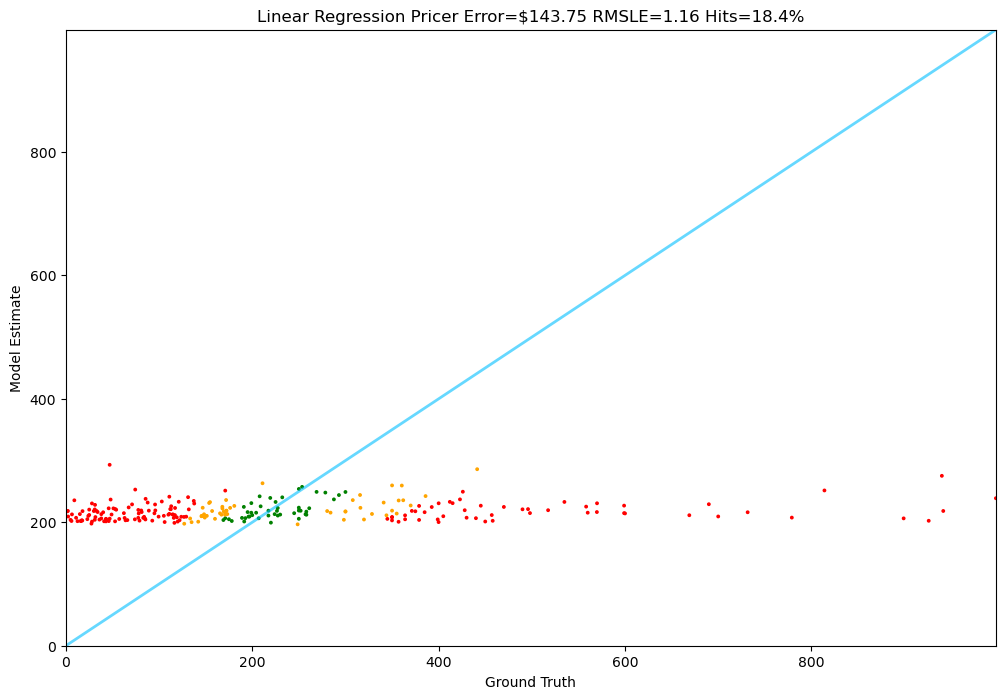

In [42]:
# test it

Tester.test(linear_regression_pricer)

In [43]:
# For the next few models, we prepare our documents and prices
# Note that we use the test prompt for the documents, otherwise we'll reveal the answer!!

prices = np.array([float(item.price) for item in train])
documents = [item.test_prompt() for item in train]

In [44]:
# Use the CountVectorizer for a Bag of Words model

np.random.seed(42)
vectorizer = CountVectorizer(max_features=1000, stop_words='english') #Up to 1000 important words
X = vectorizer.fit_transform(documents)
regressor = LinearRegression()
regressor.fit(X, prices)

LinearRegression()

In [45]:
def bow_lr_pricer(item):
    x = vectorizer.transform([item.test_prompt()])
    return max(regressor.predict(x)[0], 0)

1: Guess: $330.21 Truth: $250.56 Error: $79.65 SLE: 0.08 Item: NavePoint 4ft Open Frame 19 Inch 22U 4-P...
2: Guess: $236.28 Truth: $232.18 Error: $4.10 SLE: 0.00 Item: APS Premium 6in iBoard Running Boards Co...
3: Guess: $270.20 Truth: $134.87 Error: $135.33 SLE: 0.48 Item: Peerless PTT188792-BL Tub and Shower Tri...
4: Guess: $300.48 Truth: $357.09 Error: $56.61 SLE: 0.03 Item: TransDeco TD600B Stand with Mount, 85" T...
5: Guess: $134.25 Truth: $258.07 Error: $123.82 SLE: 0.42 Item: ACDelco Professional 45K5008 Front Lower...
6: Guess: $221.88 Truth: $27.95 Error: $193.93 SLE: 4.17 Item: AutoStuff - Camisasca Brushed Finish 2 H...
7: Guess: $231.33 Truth: $170.99 Error: $60.34 SLE: 0.09 Item: HJC Helmets Unisex-Adult Full Face i10 H...
8: Guess: $257.60 Truth: $225.00 Error: $32.60 SLE: 0.02 Item: Magnetic Roller Tip Standard Kit
9: Guess: $325.07 Truth: $105.09 Error: $219.98 SLE: 1.26 Item: Linksys by Cisco Wireless G Broadband Ro...
10: Guess: $262.72 Truth: $299.99 Error: $37.2

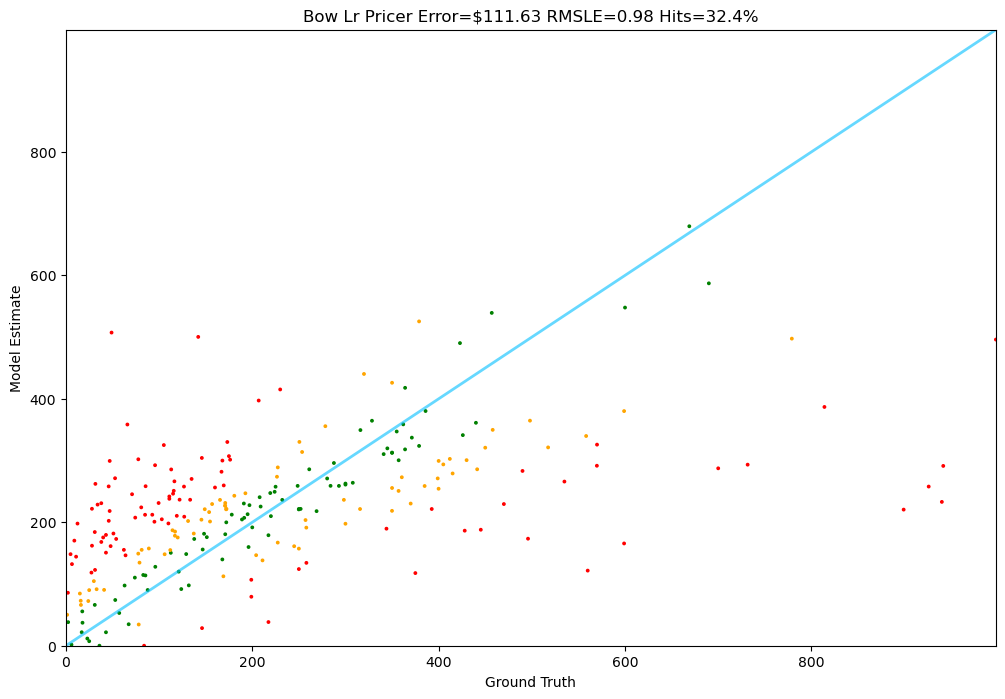

In [46]:
# test it

Tester.test(bow_lr_pricer)

In [47]:
# The amazing word2vec model, implemented in gensim NLP library

np.random.seed(42)

# Preprocess the documents
processed_docs = [simple_preprocess(doc) for doc in documents]

In [48]:
# Train Word2Vec model
w2v_model = Word2Vec(sentences=processed_docs, vector_size=400, window=5, min_count=1, workers=8)

In [49]:
# This step of averaging vectors across the document is a weakness in our approach
#word_vectors = [
#  [0.1, 0.2, ..., 0.3],   # word 1
#  [0.0, 0.1, ..., 0.2],   # word 2
#  [0.2, 0.3, ..., 0.1]    # word 3
#]
#np.mean(word_vectors, axis=0)
#computes
#[mean of column 1, mean of column 2, ..., mean of column 400]

def document_vector(doc):
    doc_words = simple_preprocess(doc) # Take a document and tokenize it.
    word_vectors = [w2v_model.wv[word] for word in doc_words if word in w2v_model.wv] # Convert each word into vector
    return np.mean(word_vectors, axis=0) if word_vectors else np.zeros(w2v_model.vector_size) # Average across words, in the end whe have, for a single document, a vector of size "vector_size"

# Create feature matrix
X_w2v = np.array([document_vector(doc) for doc in documents])

In [50]:
# Run Linear Regression on word2vec

word2vec_lr_regressor = LinearRegression()
word2vec_lr_regressor.fit(X_w2v, prices)

LinearRegression()

In [51]:
def word2vec_lr_pricer(item):
    doc = item.test_prompt()
    doc_vector = document_vector(doc)
    return max(0, word2vec_lr_regressor.predict([doc_vector])[0])

1: Guess: $385.49 Truth: $250.56 Error: $134.93 SLE: 0.18 Item: NavePoint 4ft Open Frame 19 Inch 22U 4-P...
2: Guess: $259.87 Truth: $232.18 Error: $27.69 SLE: 0.01 Item: APS Premium 6in iBoard Running Boards Co...
3: Guess: $234.55 Truth: $134.87 Error: $99.68 SLE: 0.30 Item: Peerless PTT188792-BL Tub and Shower Tri...
4: Guess: $295.04 Truth: $357.09 Error: $62.05 SLE: 0.04 Item: TransDeco TD600B Stand with Mount, 85" T...
5: Guess: $139.47 Truth: $258.07 Error: $118.60 SLE: 0.37 Item: ACDelco Professional 45K5008 Front Lower...
6: Guess: $185.40 Truth: $27.95 Error: $157.45 SLE: 3.47 Item: AutoStuff - Camisasca Brushed Finish 2 H...
7: Guess: $320.52 Truth: $170.99 Error: $149.53 SLE: 0.39 Item: HJC Helmets Unisex-Adult Full Face i10 H...
8: Guess: $229.86 Truth: $225.00 Error: $4.86 SLE: 0.00 Item: Magnetic Roller Tip Standard Kit
9: Guess: $300.92 Truth: $105.09 Error: $195.83 SLE: 1.09 Item: Linksys by Cisco Wireless G Broadband Ro...
10: Guess: $215.08 Truth: $299.99 Error: $84.

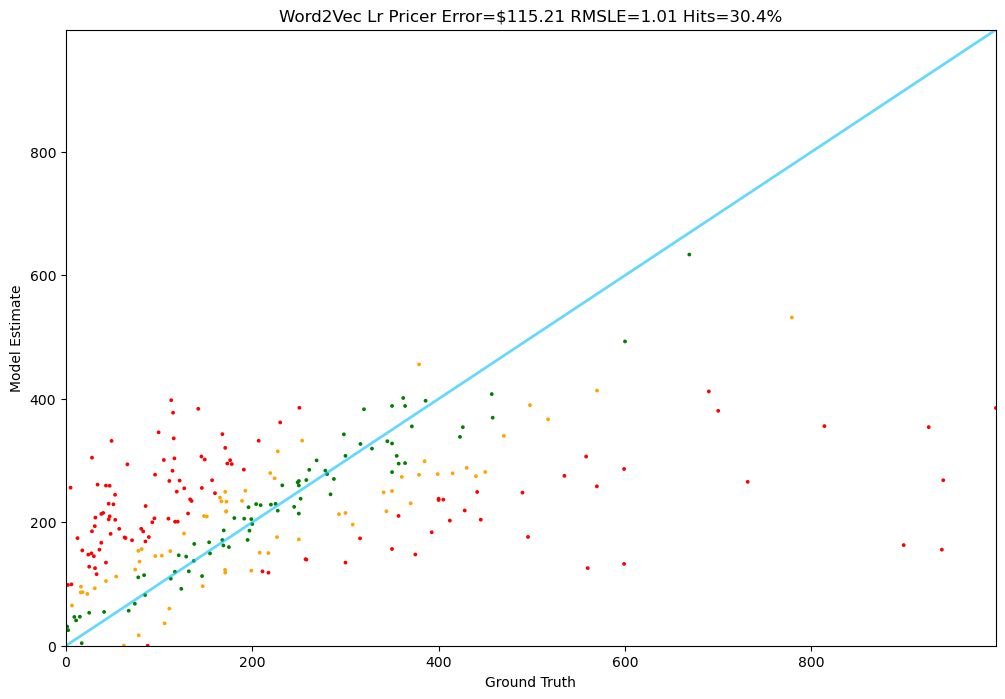

In [52]:
Tester.test(word2vec_lr_pricer)

In [53]:
# Support Vector Machines

np.random.seed(42)
svr_regressor = LinearSVR()

svr_regressor.fit(X_w2v, prices)

LinearSVR()

In [54]:
def svr_pricer(item):
    np.random.seed(42)
    doc = item.test_prompt()
    doc_vector = document_vector(doc)
    return max(float(svr_regressor.predict([doc_vector])[0]),0)

1: Guess: $300.37 Truth: $250.56 Error: $49.81 SLE: 0.03 Item: NavePoint 4ft Open Frame 19 Inch 22U 4-P...
2: Guess: $222.32 Truth: $232.18 Error: $9.86 SLE: 0.00 Item: APS Premium 6in iBoard Running Boards Co...
3: Guess: $183.00 Truth: $134.87 Error: $48.13 SLE: 0.09 Item: Peerless PTT188792-BL Tub and Shower Tri...
4: Guess: $224.41 Truth: $357.09 Error: $132.68 SLE: 0.21 Item: TransDeco TD600B Stand with Mount, 85" T...
5: Guess: $114.34 Truth: $258.07 Error: $143.73 SLE: 0.65 Item: ACDelco Professional 45K5008 Front Lower...
6: Guess: $164.79 Truth: $27.95 Error: $136.84 SLE: 3.05 Item: AutoStuff - Camisasca Brushed Finish 2 H...
7: Guess: $254.85 Truth: $170.99 Error: $83.86 SLE: 0.16 Item: HJC Helmets Unisex-Adult Full Face i10 H...
8: Guess: $152.35 Truth: $225.00 Error: $72.65 SLE: 0.15 Item: Magnetic Roller Tip Standard Kit
9: Guess: $230.12 Truth: $105.09 Error: $125.03 SLE: 0.61 Item: Linksys by Cisco Wireless G Broadband Ro...
10: Guess: $221.93 Truth: $299.99 Error: $78.0

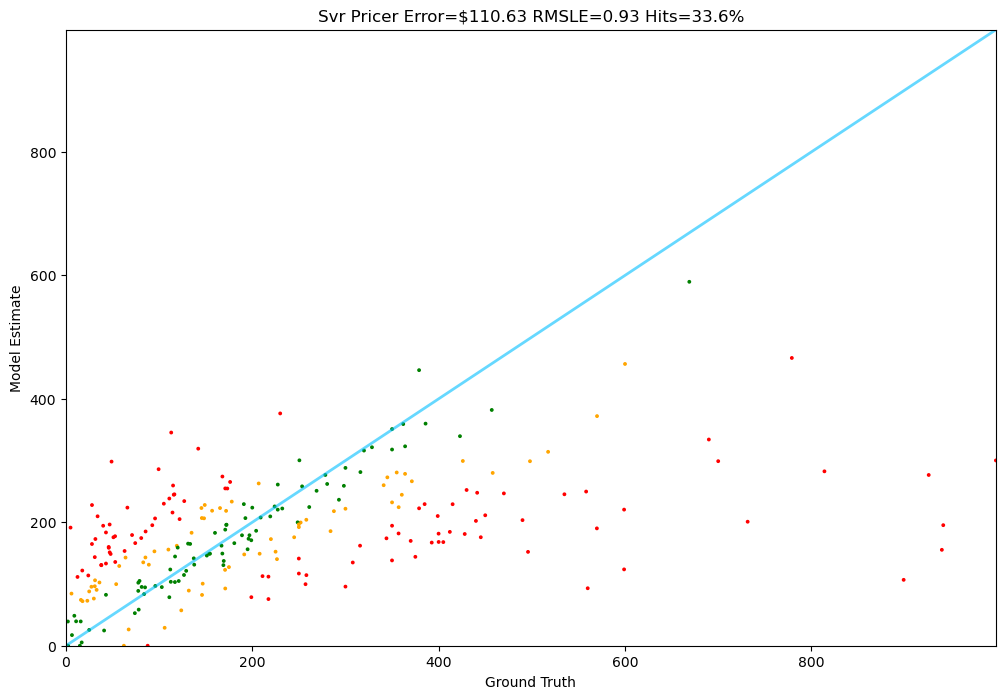

In [55]:
Tester.test(svr_pricer)

In [58]:
# And the powerful Random Forest regression

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=4)
rf_model.fit(X_w2v, prices)

KeyboardInterrupt: 

In [ ]:
def random_forest_pricer(item):
    doc = item.test_prompt()
    doc_vector = document_vector(doc)
    return max(0, rf_model.predict([doc_vector])[0])

In [ ]:
Tester.test(random_forest_pricer)

In [56]:
from lightgbm import LGBMRegressor
lgb_model = LGBMRegressor(n_estimators=400, random_state=42, learning_rate=0.01, n_jobs=-1)
lgb_model.fit(X_w2v, prices)
def lgb_pricer(item):
    doc = item.test_prompt()
    doc_vector = document_vector(doc)
    return max(0, lgb_model.predict([doc_vector])[0])

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.831314 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 102000
[LightGBM] [Info] Number of data points in the train set: 400000, number of used features: 400
[LightGBM] [Info] Start training from score 220.453399


In [17]:
# Setup cross-validation
SEED = 42
import optuna
from lightgbm import LGBMRegressor
from sklearn.model_selection import KFold

skf = KFold(n_splits=3, shuffle=True, random_state=SEED)
def objective(trial):

    # Suggest values for the hyperparameters
    random_state = 42
    verbosity = -1
    objective = 'regression'
    boosting_type = 'gbdt'
    n_estimators = trial.suggest_int('n_estimators', 100, 500) #100, 500)    
    reg_alpha = trial.suggest_float('reg_alpha', 0.001, 0.1)
    reg_lambda = trial.suggest_float('reg_lambda', 0.001, 0.1)
    learning_rate = trial.suggest_float('learning_rate', 0.001, 1.0, log=True)
    max_depth = trial.suggest_int('max_depth', 20, 50)    
    num_leaves = trial.suggest_int('num_leaves', 2, 200) #100)
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.1, 1.0)
    min_child_samples = trial.suggest_int('min_child_samples', 10, 50)
    subsample_freq = trial.suggest_int('subsample_freq', 0, 15) 

    errors = []

    for train_idx, val_idx in skf.split(X_w2v, prices):

        # Create the folds
        X_train_fold, X_val_fold = X_w2v[train_idx], X_w2v[val_idx]
        y_train_fold, y_val_fold = prices[train_idx], prices[val_idx]

        # Instantiate the model
        lgb_model = LGBMRegressor(
            random_state=random_state,
            verbosity=verbosity,
            objective=objective,
            boosting_type=boosting_type,                                   
            n_estimators=n_estimators,
            reg_alpha=reg_alpha,
            reg_lambda=reg_lambda,
            learning_rate=learning_rate,
            max_depth=max_depth,
            num_leaves=num_leaves,
            colsample_bytree=colsample_bytree,
            min_child_samples=min_child_samples,
            subsample_freq=subsample_freq            
            )
    
        # Train the model
        lgb_model.fit(X_train_fold, y_train_fold)

        # Predict on the validation set
        preds = lgb_model.predict(X_val_fold)
        preds = np.maximum(0, preds)  # Clip negative predictions to 0
        
        error = np.abs(preds - y_val_fold)
        errors.append(np.mean(error))

    return np.mean(errors)
    
# Create a study object with 'maximize' direction
study = optuna.create_study(direction='minimize')

# Start the optimization
study.optimize(objective, n_trials=100, n_jobs=-1)

# Get the best trial
best_trial = study.best_trial

print(f'Best trial number: {best_trial.number}')
print(f'Best value (partial auc - 0.8): {best_trial.value}')
print(f'Best hyperparameters: {best_trial.params}')

[I 2025-06-23 17:27:37,299] A new study created in memory with name: no-name-324ccbc7-bc1b-478d-ab31-eb88830c6094
[W 2025-06-23 17:27:37,303] Trial 0 failed with parameters: {'n_estimators': 314, 'reg_alpha': 0.07338822603439207, 'reg_lambda': 0.04318294787141395, 'learning_rate': 0.0019186169507363958, 'max_depth': 34, 'num_leaves': 86, 'colsample_bytree': 0.4672106609286568, 'min_child_samples': 42, 'subsample_freq': 7} because of the following error: NameError("name 'X_w2v' is not defined").
Traceback (most recent call last):
  File "c:\Users\ssre_\.conda\envs\.venv_llms\Lib\site-packages\optuna\study\_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\ssre_\AppData\Local\Temp\ipykernel_17300\2000603934.py", line 27, in objective
    for train_idx, val_idx in skf.split(X_w2v, prices):
                                        ^^^^^
NameError: name 'X_w2v' is not defined
[W 2025-06-23 17:27:37,305] Trial 1 failed w

NameError: name 'X_w2v' is not defined

c:\Users\ssre_\.conda\envs\.venv_llms\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\ssre_\.conda\envs\.venv_llms\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\ssre_\.conda\envs\.venv_llms\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\ssre_\.conda\envs\.venv_llms\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\ssre_\.conda\envs\.venv_llms\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with featur

1: Guess: $305.43 Truth: $250.56 Error: $54.87 SLE: 0.04 Item: NavePoint 4ft Open Frame 19 Inch 22U 4-P...
2: Guess: $245.06 Truth: $232.18 Error: $12.88 SLE: 0.00 Item: APS Premium 6in iBoard Running Boards Co...
3: Guess: $258.41 Truth: $134.87 Error: $123.54 SLE: 0.42 Item: Peerless PTT188792-BL Tub and Shower Tri...
4: Guess: $317.90 Truth: $357.09 Error: $39.19 SLE: 0.01 Item: TransDeco TD600B Stand with Mount, 85" T...
5: Guess: $189.98 Truth: $258.07 Error: $68.09 SLE: 0.09 Item: ACDelco Professional 45K5008 Front Lower...
6: Guess: $213.38 Truth: $27.95 Error: $185.43 SLE: 4.01 Item: AutoStuff - Camisasca Brushed Finish 2 H...
7: Guess: $219.43 Truth: $170.99 Error: $48.44 SLE: 0.06 Item: HJC Helmets Unisex-Adult Full Face i10 H...
8: Guess: $187.85 Truth: $225.00 Error: $37.15 SLE: 0.03 Item: Magnetic Roller Tip Standard Kit
9: Guess: $291.27 Truth: $105.09 Error: $186.18 SLE: 1.03 Item: Linksys by Cisco Wireless G Broadband Ro...
10: Guess: $260.25 Truth: $299.99 Error: $39.7

c:\Users\ssre_\.conda\envs\.venv_llms\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\ssre_\.conda\envs\.venv_llms\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\ssre_\.conda\envs\.venv_llms\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\ssre_\.conda\envs\.venv_llms\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\ssre_\.conda\envs\.venv_llms\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with featur

128: Guess: $223.33 Truth: $449.99 Error: $226.66 SLE: 0.49 Item: MasterTop Replacement Soft Top in Black ...
129: Guess: $233.35 Truth: $188.96 Error: $44.39 SLE: 0.04 Item: ICOM 2300H 05 144MHz Amateur Radio
130: Guess: $184.60 Truth: $121.09 Error: $63.51 SLE: 0.18 Item: Porsche Genuine Accessories 98704480093 ...
131: Guess: $241.19 Truth: $204.14 Error: $37.05 SLE: 0.03 Item: ITP Blackwater Evolution Mud Terrain ATV...
132: Guess: $287.65 Truth: $349.99 Error: $62.34 SLE: 0.04 Item: NETVANTA 1200 POE (1702595G1)
133: Guess: $243.16 Truth: $34.00 Error: $209.16 SLE: 3.77 Item: Gravity Car Alarm & Keyless Entry System...
134: Guess: $260.42 Truth: $384.95 Error: $124.53 SLE: 0.15 Item: MINKA-AIRE F518L-BN Concept II LED Brush...
135: Guess: $183.82 Truth: $210.99 Error: $27.17 SLE: 0.02 Item: Delphi FG0852 Fuel Module
136: Guess: $187.05 Truth: $129.09 Error: $57.96 SLE: 0.14 Item: Replacement for EGO 56V Battery,5.0 Ah L...
137: Guess: $173.61 Truth: $110.99 Error: $62.62 SLE: 0.20

c:\Users\ssre_\.conda\envs\.venv_llms\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\ssre_\.conda\envs\.venv_llms\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\ssre_\.conda\envs\.venv_llms\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\ssre_\.conda\envs\.venv_llms\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\ssre_\.conda\envs\.venv_llms\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with featur

193: Guess: $213.45 Truth: $207.90 Error: $5.55 SLE: 0.00 Item: Behr Hella Service 351041681 HVAC Blower...
194: Guess: $224.00 Truth: $171.90 Error: $52.10 SLE: 0.07 Item: WILD ABOUT CARTS Yamaha Drive G29 LED De...
195: Guess: $230.19 Truth: $292.99 Error: $62.80 SLE: 0.06 Item: Covercraft Carhartt SeatSaver Front Row ...
196: Guess: $170.53 Truth: $375.00 Error: $204.47 SLE: 0.62 Item: Interior Innovations Custom Front Synthe...
197: Guess: $215.97 Truth: $112.00 Error: $103.97 SLE: 0.43 Item: DTA D930-027+NT515050 x2-2 Front Wheel H...
198: Guess: $139.19 Truth: $42.99 Error: $96.20 SLE: 1.34 Item: Kirigen Wood 3-Tier Office Desktop Docum...
199: Guess: $181.81 Truth: $116.99 Error: $64.82 SLE: 0.19 Item: JUDU Vintage Tiffany Style Stained Glass...
200: Guess: $248.45 Truth: $119.00 Error: $129.45 SLE: 0.54 Item: Games Workshop 99120103034" Warhammer 40...
201: Guess: $161.19 Truth: $146.79 Error: $14.40 SLE: 0.01 Item: LBRST Headlight Assembly For Chrysler To...
202: Guess: $175.0

c:\Users\ssre_\.conda\envs\.venv_llms\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\ssre_\.conda\envs\.venv_llms\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\ssre_\.conda\envs\.venv_llms\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\ssre_\.conda\envs\.venv_llms\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\ssre_\.conda\envs\.venv_llms\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with featur

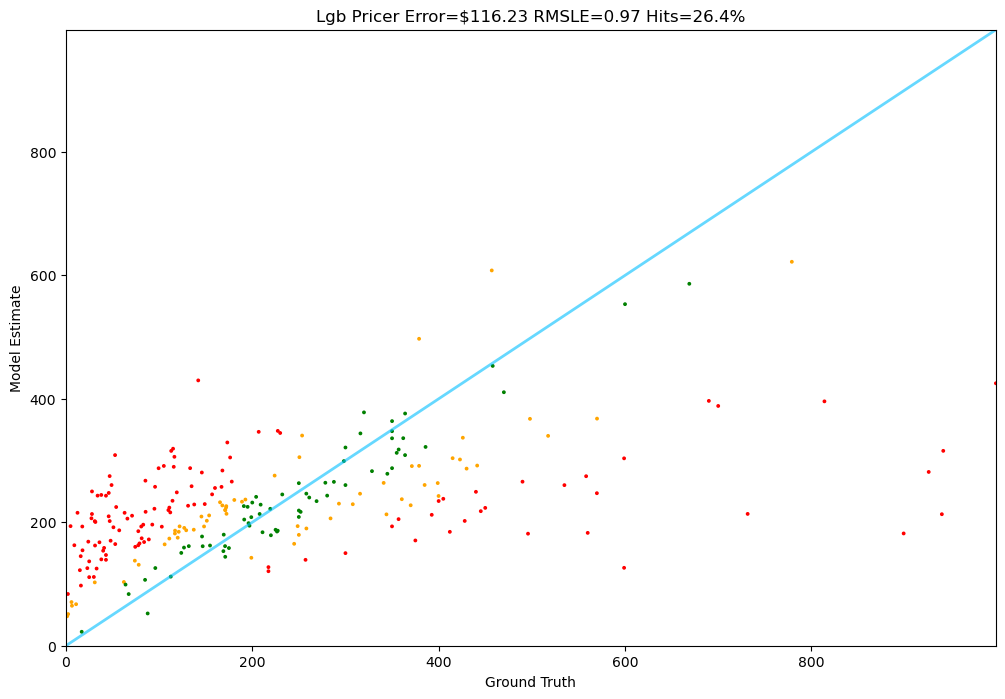

In [57]:
Tester.test(lgb_pricer)